In [1]:
import chemprop as cp
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    matthews_corrcoef
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit

import deltaprop
import wandb
from tuner import tune_model
from utils import (
    RANDOM_SEED,
    generate_features,
    get_scaffold,
    mol_to_inchi,
    standardize,
)

wandb.login(key="cf344975eb80edf6f0d52af80528cc6094234caf")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/rahul/.netrc
wandb: Currently logged in as: rahul-e-dev to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [2]:
df = pd.read_excel("./evaluate_tba/GSK_TBA_AH_JSFedit070425.xlsx")
df["reg_target"] = df["parent_remaining_24"].round(1) / 100 + df["metabolite_detected"]
df["label"] = df["reg_target"] > 1.5

df = df.loc[
    :, ["smiles", "parent_remaining_24", "metabolite_detected", "reg_target", "label"]
]
df["mol"] = df["smiles"].map(standardize)
df = df.dropna(subset=["mol"])
df["inchi"] = df["mol"].map(mol_to_inchi)
df = df.groupby(["inchi"]).filter(lambda x: len(x) == 1).reset_index(drop=True)

df = generate_features(df)

clusters, _ = pd.factorize(df["mol"].map(get_scaffold))
df["cluster"] = pd.Series(clusters)

df = df.drop("inchi", axis=1)

In [3]:
def get_molecule_datapoint(row):
    feat_entry_names = [f for f in row.index if f.startswith("feat")]
    if len(feat_entry_names) > 0:
        feat_array = pd.to_numeric(row[feat_entry_names], errors="coerce")
    else:
        feat_array = None

    return cp.data.MoleculeDatapoint(
        mol=row["mol"], y=np.array([row["reg_target"]]), x_d=feat_array
    )


df["mol_dp"] = df.apply(get_molecule_datapoint, axis=1)

In [4]:
def generate_repeated_5x5_splits(df):
    rng = np.random.RandomState(RANDOM_SEED)
    for outer_idx in range(5):
        randint = rng.randint(low=0, high=32767)
        cv = GroupKFold(n_splits=5, shuffle=True, random_state=randint)  # type: ignore
        for inner_idx, (train_val_idxs, test_idxs) in enumerate(
            cv.split(df, groups=df["cluster"])
        ):
            train_val_df = df.loc[train_val_idxs].reset_index(drop=True)
            test_df = df.loc[test_idxs].reset_index(drop=True)

            train_idx, val_idxs = next(
                GroupShuffleSplit(1, random_state=randint).split(
                    train_val_df, groups=train_val_df["cluster"]
                )
            )

            train_df = train_val_df.loc[train_idx].reset_index(drop=True)
            val_df = train_val_df.loc[val_idxs].reset_index(drop=True)

            yield (outer_idx, inner_idx), (train_df, val_df, test_df)


def generate_repeated_5x2_splits(df):
    rng = np.random.RandomState(RANDOM_SEED)
    for outer_idx in range(5):
        randint = rng.randint(low=0, high=32767)
        cv = GroupKFold(n_splits=2, shuffle=True, random_state=randint)  # type: ignore
        for inner_idx, (train_idxs, val_test_idxs) in enumerate(
            cv.split(df, groups=df["cluster"])
        ):
            train_df = df.loc[train_idxs].reset_index(drop=True)
            val_test_df = df.loc[val_test_idxs].reset_index(drop=True)

            val_idxs, test_idxs = next(
                GroupShuffleSplit(1, test_size=0.5, random_state=randint).split(
                    val_test_df, groups=val_test_df["cluster"]
                )
            )

            val_df = val_test_df.loc[val_idxs].reset_index(drop=True)
            test_df = val_test_df.loc[test_idxs].reset_index(drop=True)

            yield (outer_idx, inner_idx), (train_df, val_df, test_df)

In [5]:
def prepare_mol_datasets(train_df, val_df, test_df):
    featurizer = cp.featurizers.SimpleMoleculeMolGraphFeaturizer()
    train_mol_dataset = cp.data.MoleculeDataset(
        train_df["mol_dp"], featurizer=featurizer
    )
    val_mol_dataset = cp.data.MoleculeDataset(val_df["mol_dp"], featurizer=featurizer)
    test_mol_dataset = cp.data.MoleculeDataset(test_df["mol_dp"], featurizer=featurizer)

    x_d_scaler = train_mol_dataset.normalize_inputs("X_d")
    val_mol_dataset.normalize_inputs("X_d", x_d_scaler)

    train_mol_dataset.cache = True
    val_mol_dataset.cache = True

    return train_mol_dataset, val_mol_dataset, test_mol_dataset, x_d_scaler

In [6]:
def calc_metrics(pred_probs, preds, labels):
    return {
        "accuracy": accuracy_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "mcc": matthews_corrcoef(labels, preds),
        "roc_auc": roc_auc_score(labels, pred_probs),
        "average_precision": average_precision_score(labels, pred_probs),
    }

In [ ]:
run = wandb.init(project="evaluate_tba", tags=["deltaprop"])
run.mark_preempting()

results = []
for idx, (split_idxs, split) in enumerate(generate_repeated_5x2_splits(df)):
    outer_idx, inner_idx = split_idxs
    train_df, val_df, test_df = split

    train_mol_ds, val_mol_ds, test_mol_ds, X_d_scaler = prepare_mol_datasets(
        train_df, val_df, test_df
    )

    # best_config = tune_model(
    #     tune_func=deltaprop.tune_func,
    #     search_space=deltaprop.search_space,
    #     train_mol_ds=train_mol_ds,
    #     val_mol_ds=val_mol_ds,
    #     X_d_scaler=X_d_scaler,
    #     batch_size=16,
    #     max_epochs=20,
    #     binary_threshold=1.5,
    #     max_concurrent=2,
    #     num_samples=10,
    # )

    best_config = {
        "depth": 1,
        "ffn_hidden_dim": 300,
        "ffn_num_layers": 1,
        "message_hidden_dim": 300,
        "batch_norm": False,
        "encoder_dropout": 0.0,
        "interaction_dropout": 0.0,
        "candidate_size": 32,
    }

    model = deltaprop.train_func(
        config=best_config,
        train_mol_ds=train_mol_ds,
        val_mol_ds=val_mol_ds,
        X_d_scaler=X_d_scaler,
        binary_threshold=1.5,
        batch_size=8,
        max_epochs=30,
        early_stopping_patience=10
    )

    exemplar_idxs = train_df[train_df["label"] == True].index.tolist()

    clf_th = deltaprop.tune_binary_classification_threshold(
        model, train_mol_ds, exemplar_idxs, val_mol_ds, val_df["label"]
    )

    pred_probs, preds = deltaprop.predict_func(
        model=model,
        binary_classification_threshold=clf_th,
        train_mol_ds=train_mol_ds,
        exemplar_idxs=exemplar_idxs,
        test_mol_ds=test_mol_ds,
    )
    results.append(
        {"outer": outer_idx, "inner": inner_idx}
        | calc_metrics(pred_probs, preds, test_df["label"])
    )
    wandb.log(
        {"outer": outer_idx, "inner": inner_idx}
        | calc_metrics(pred_probs, preds, test_df["label"])
        | best_config,
    )
    # break

results = pd.DataFrame.from_records(results)
wandb_table = wandb.Table(dataframe=results)
run.log({"split_results": wandb_table})
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.
/home/rahul/delta/.venv/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (32) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.

  | Name            | Type               | Params | Mode 
---------------------------------------------------------------
0 | message_passing | BondMessagePassing | 227 K  | train
1 | agg             | MeanAggregation    | 0      | train
2 | encoder         | Encoder            | 245 K  | train
3 | interaction     | Interaction        | 90.0 K | train
4 | bn              | Identity           | 0      | train
5 | X_d_transform   | ScaleTransform     | 0      | train
6 | ln            

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved. New best score: 0.461


Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved by 0.009 >= min_delta = 0.0. New best score: 0.419


Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
train_embeds = deltaprop.right_embed_all(train_mol_ds, model)
test_embeds = deltaprop.left_embed_all(test_mol_ds, model, scale_X_d=True)

In [ ]:
import torch

with torch.no_grad():
    pred_probs = (
        model.interaction(test_embeds, train_embeds)
        .sigmoid()
        .squeeze()
        .cpu()
        .numpy()
    )

In [ ]:
pred_probs.max()

np.float32(0.9726083)

In [ ]:
from sklearn.isotonic import IsotonicRegression
from scipy.interpolate import interp1d

def get_prob(vals, tail_probs, binary_threshold):
    sort_idxs = np.argsort(vals)
    X = vals[sort_idxs]
    Y = tail_probs[sort_idxs]
    reg = IsotonicRegression(increasing=False, y_min=0, y_max=1.0)
    adj_Y = reg.fit_transform(X, Y)
    f = interp1d(X, adj_Y, kind="linear", fill_value=(adj_Y[0], adj_Y[-1]))
    return f(binary_threshold)

In [ ]:
from tqdm.auto import tqdm
from sklearn.isotonic import IsotonicRegression
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

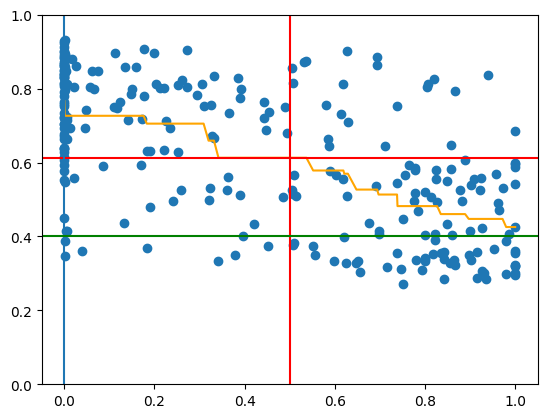

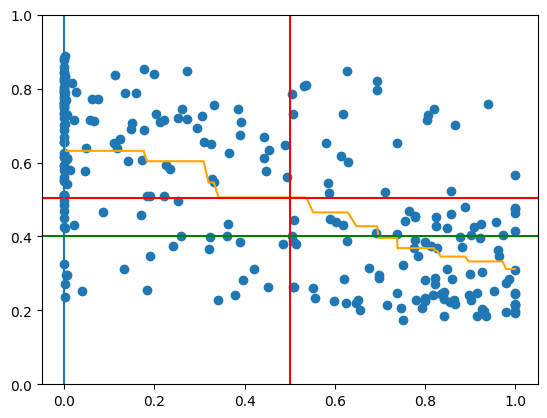

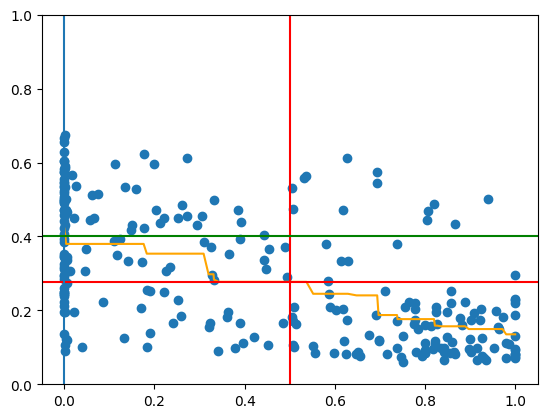

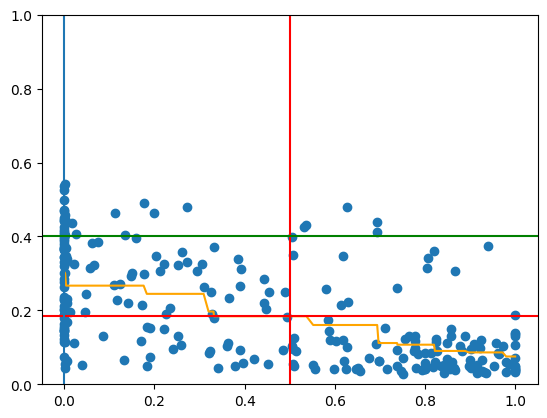

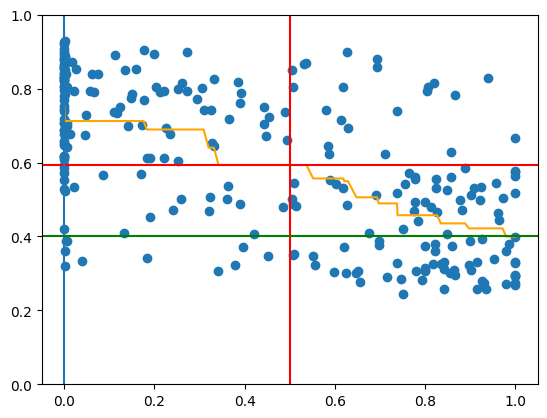

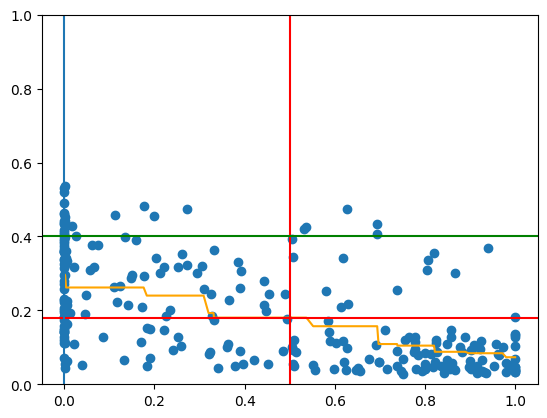

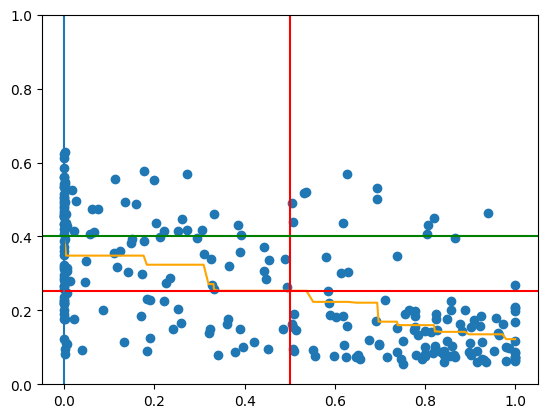

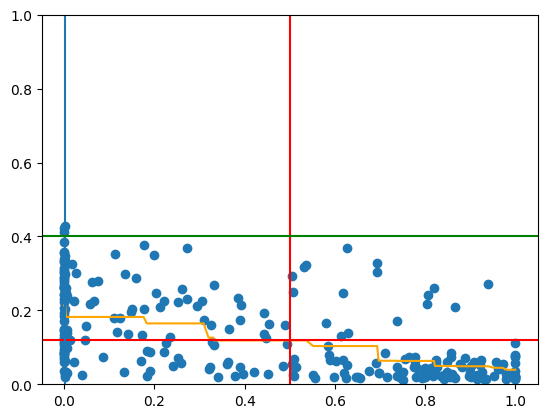

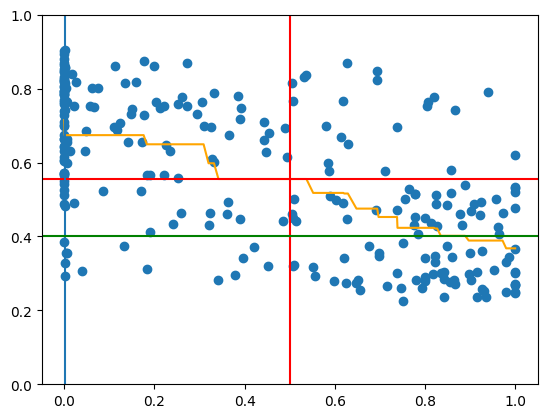

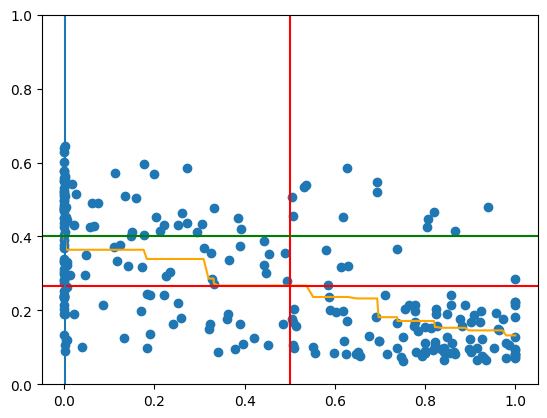

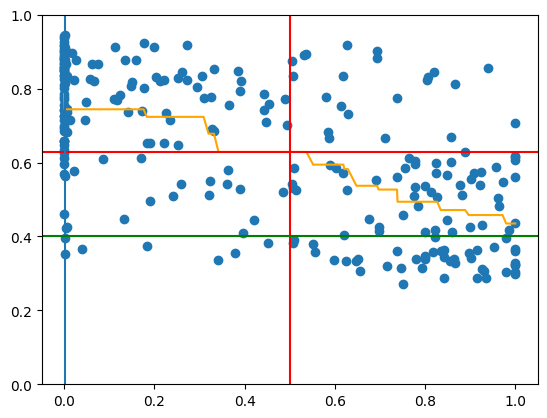

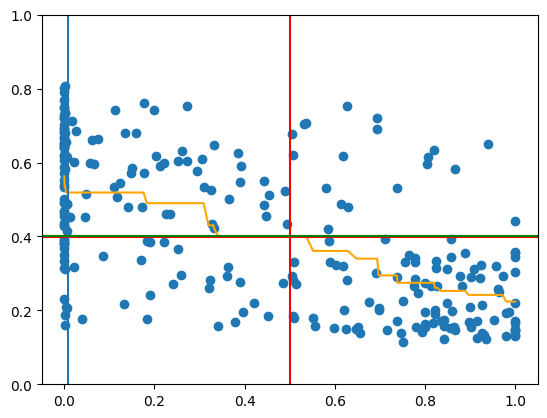

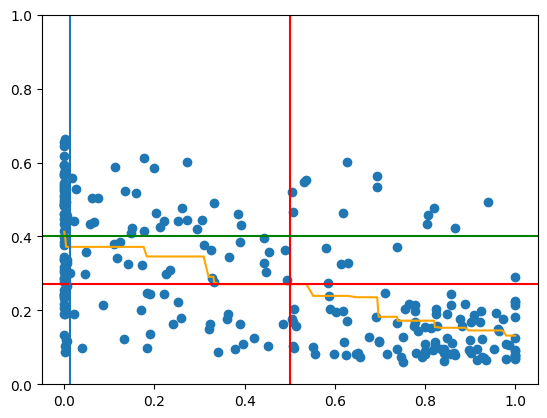

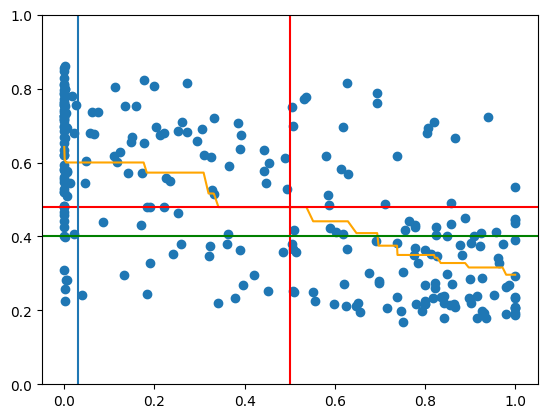

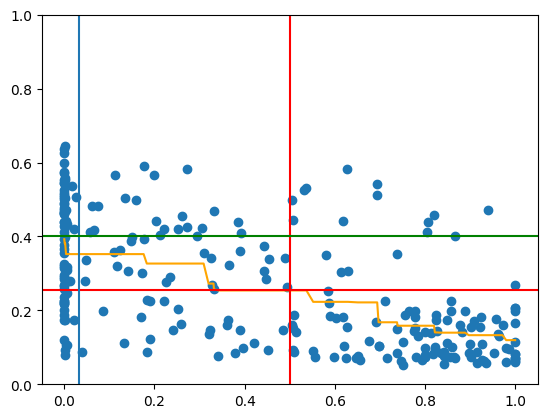

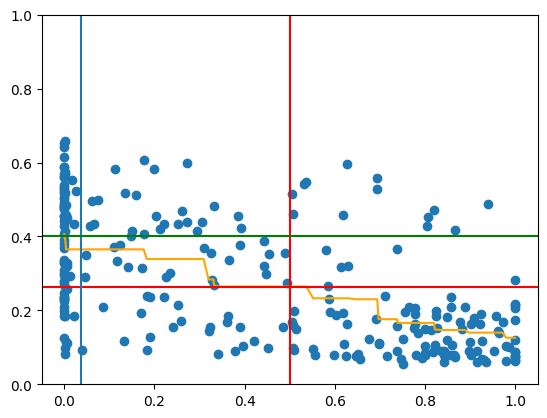

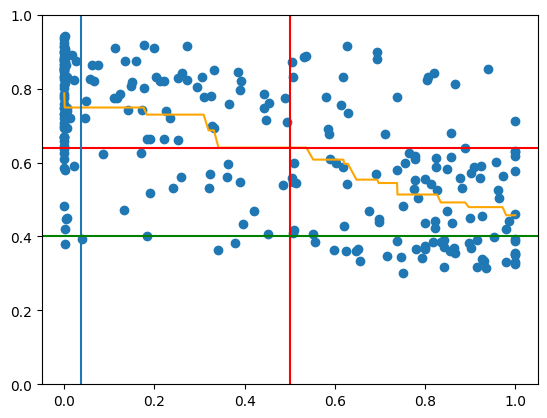

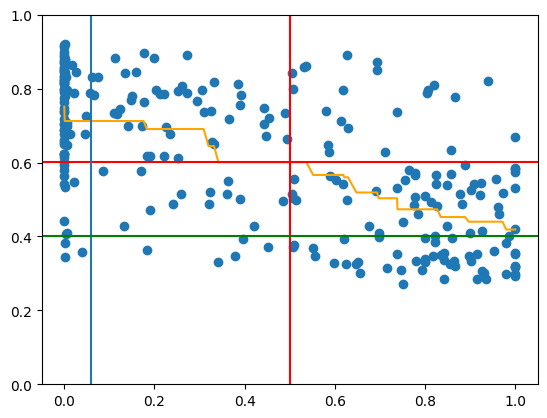

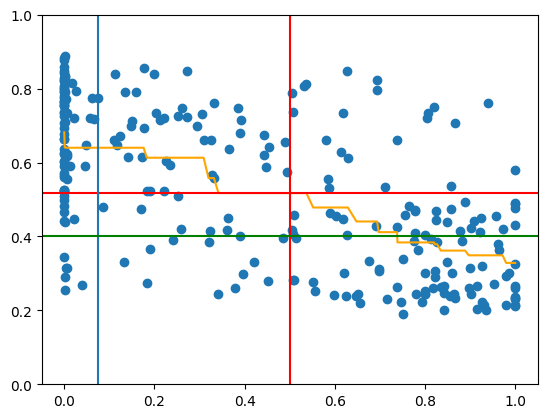

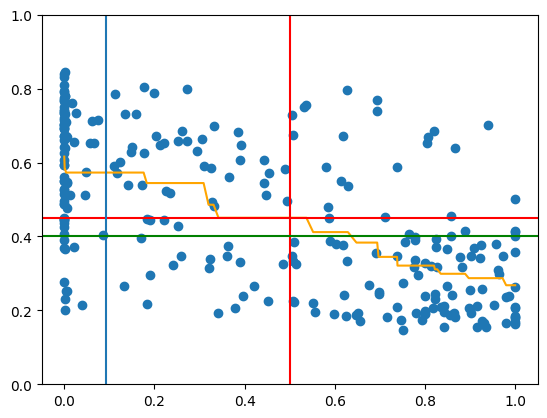

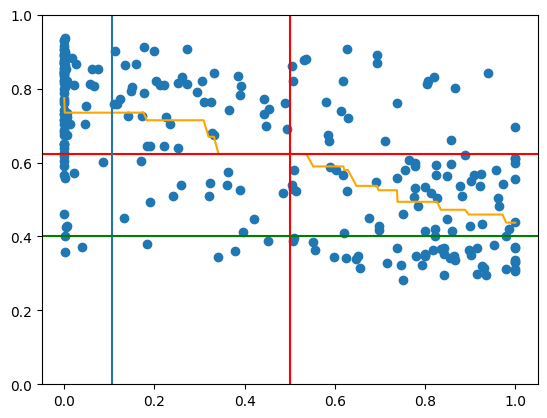

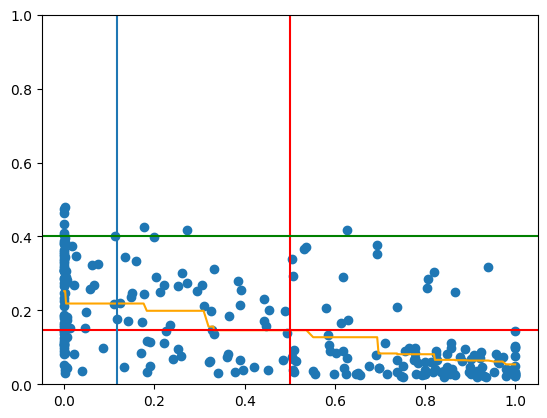

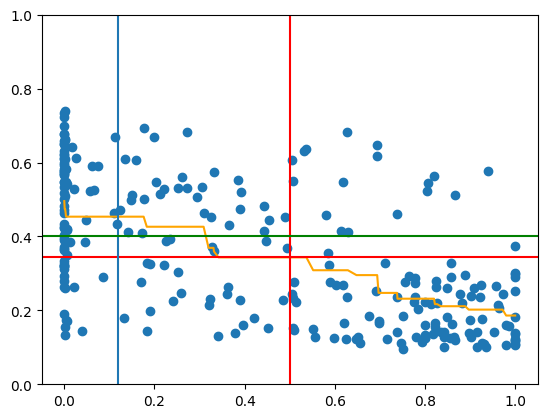

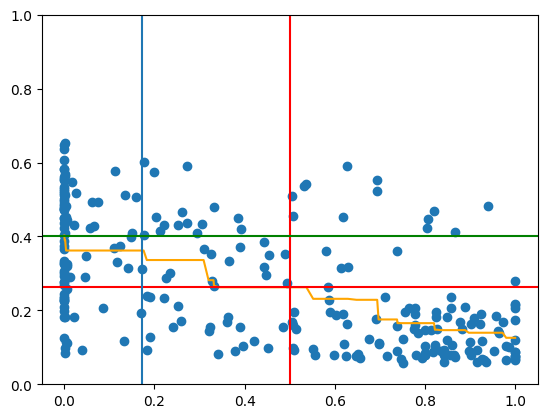

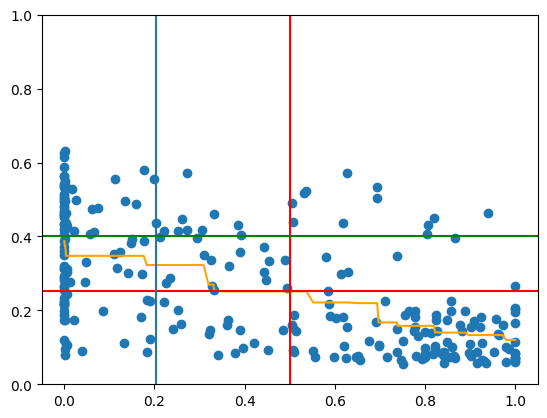

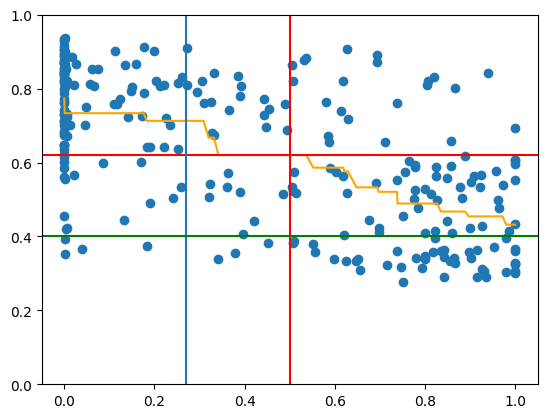

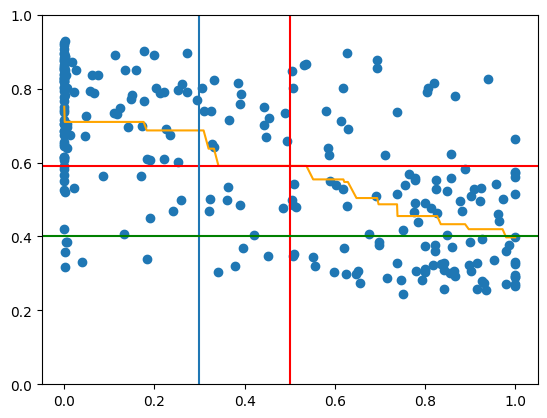

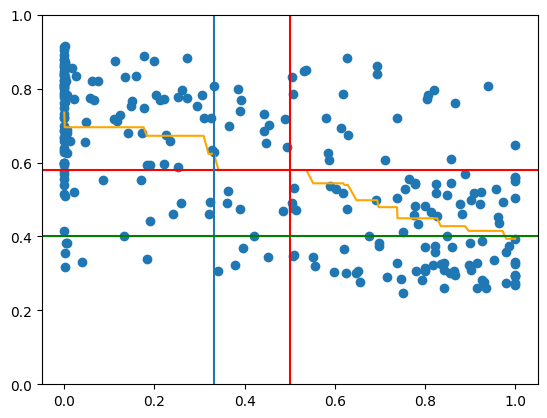

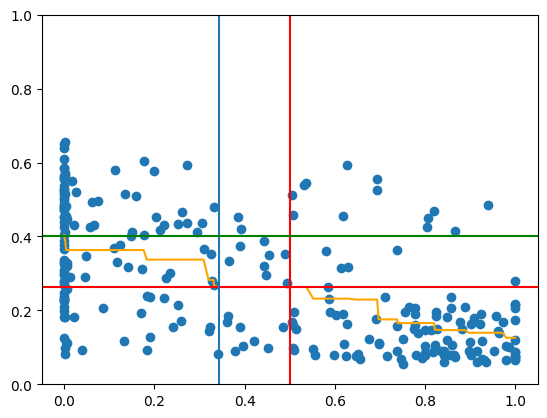

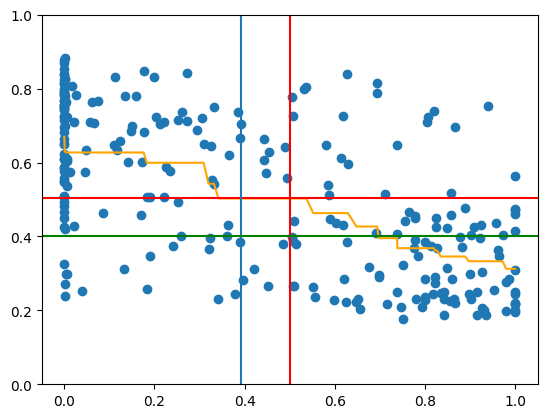

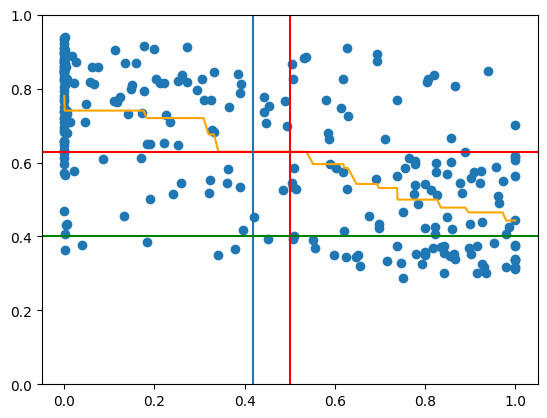

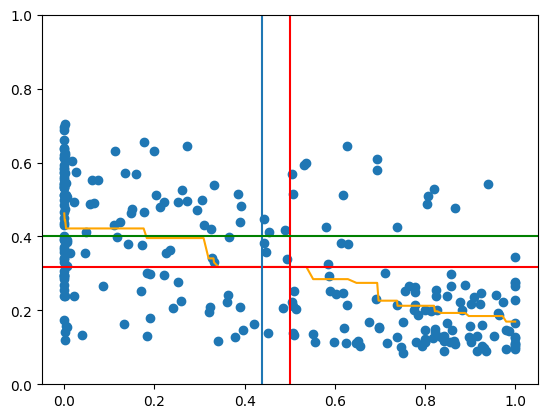

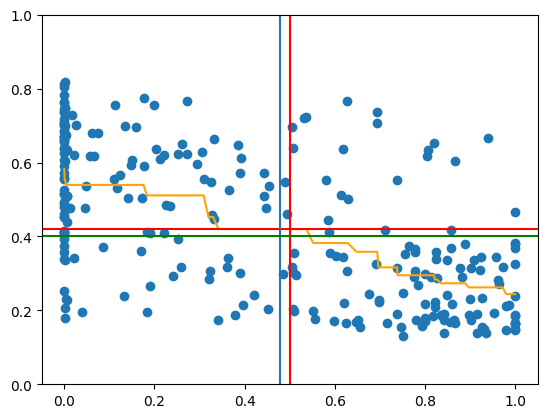

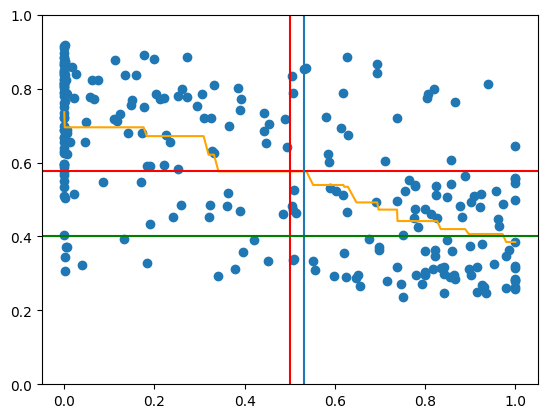

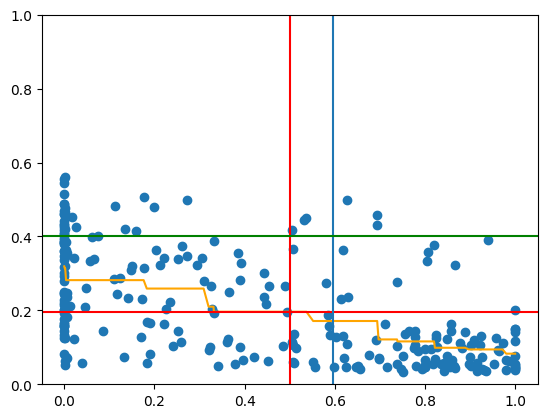

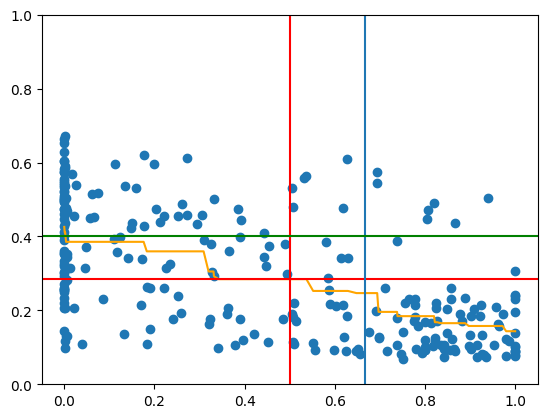

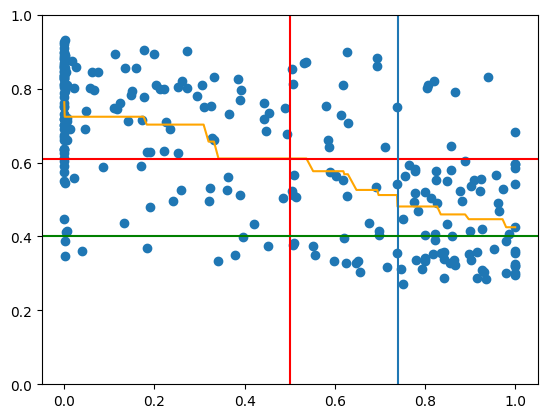

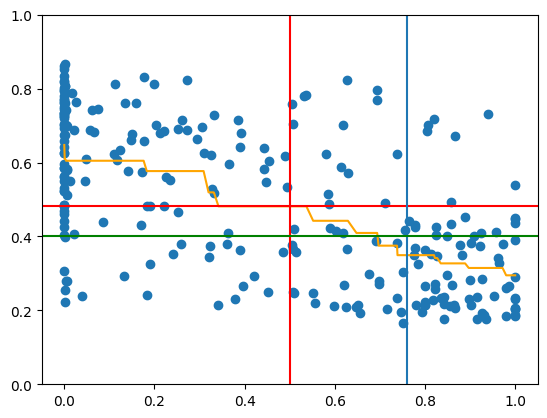

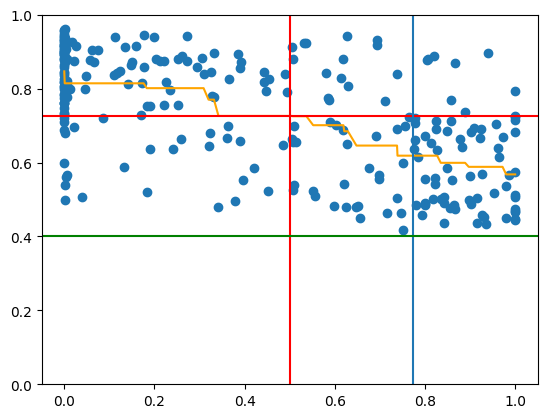

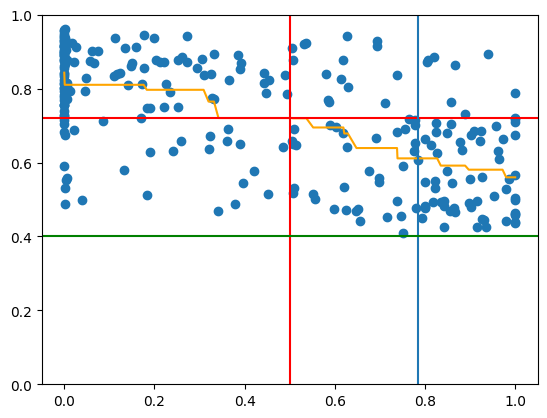

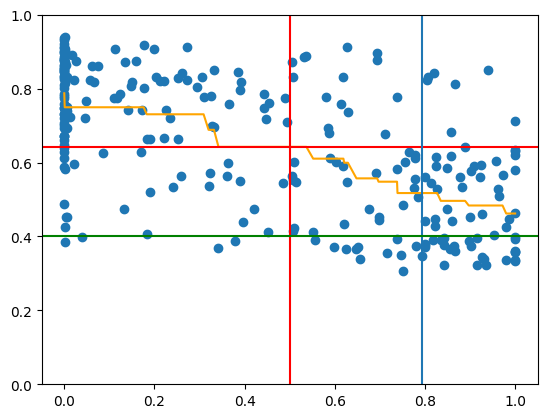

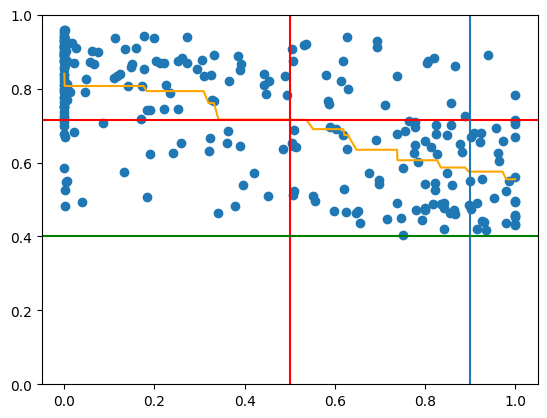

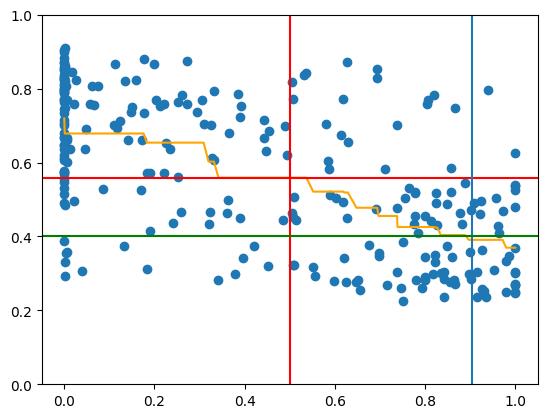

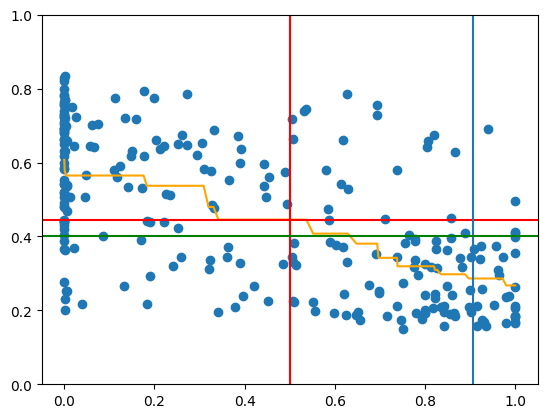

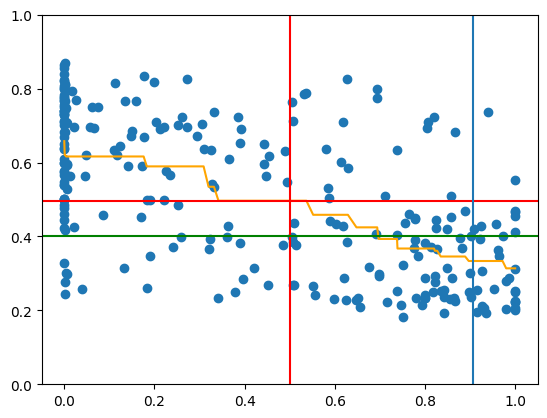

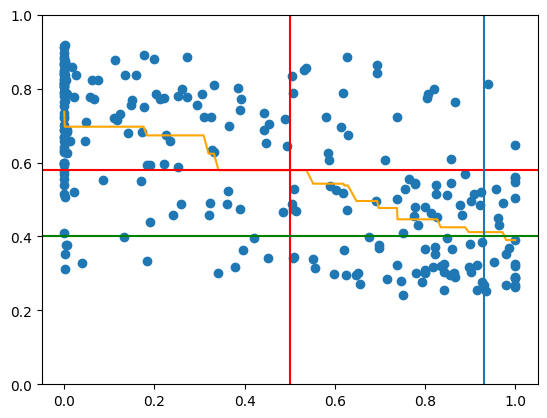

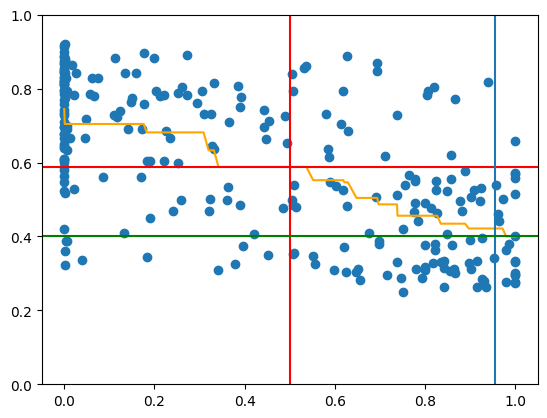

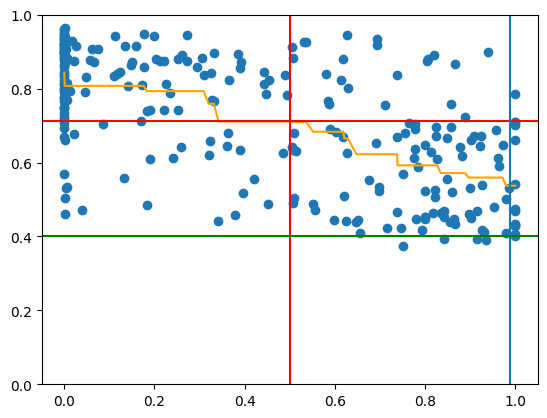

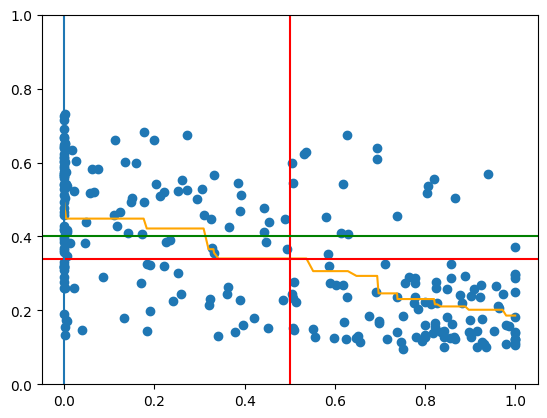

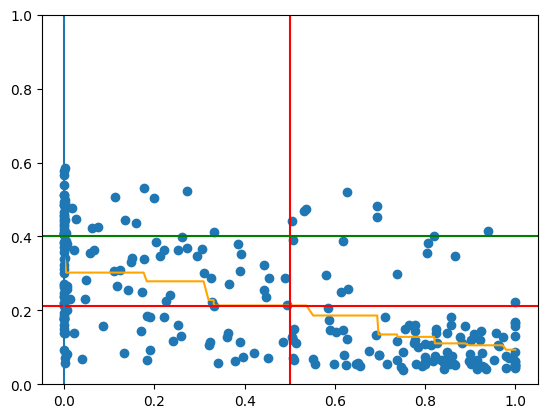

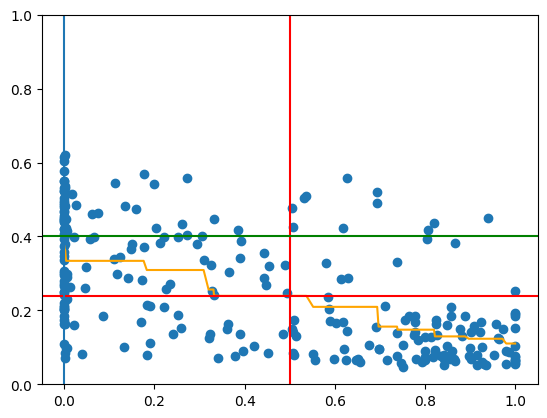

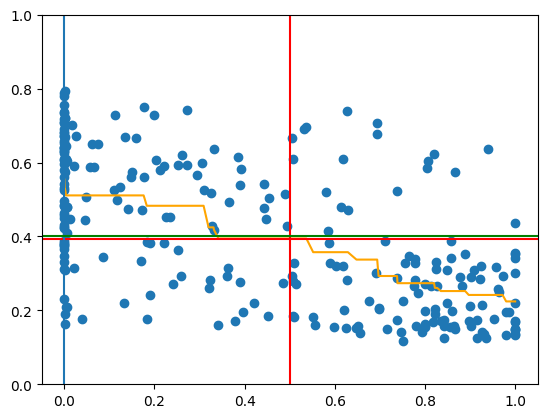

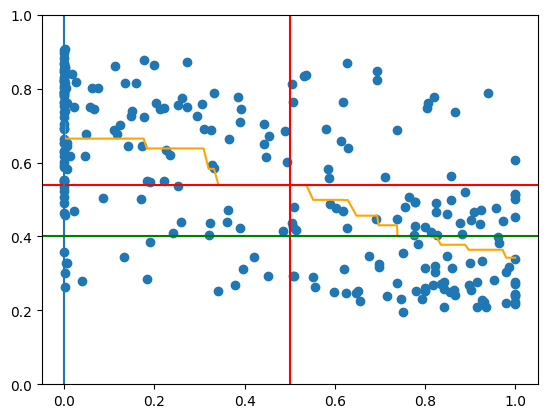

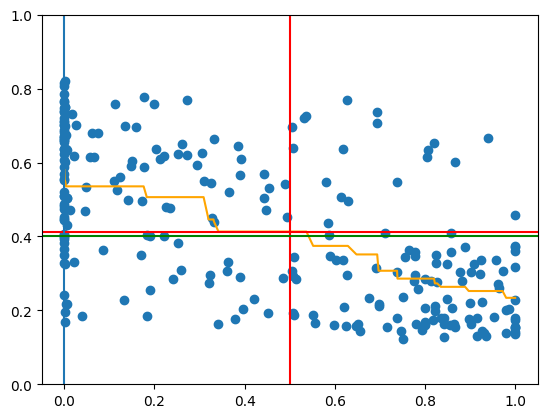

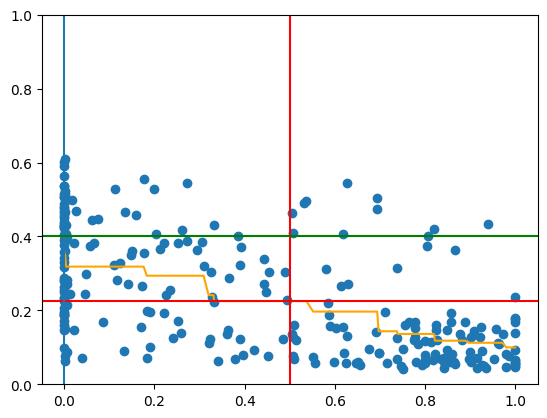

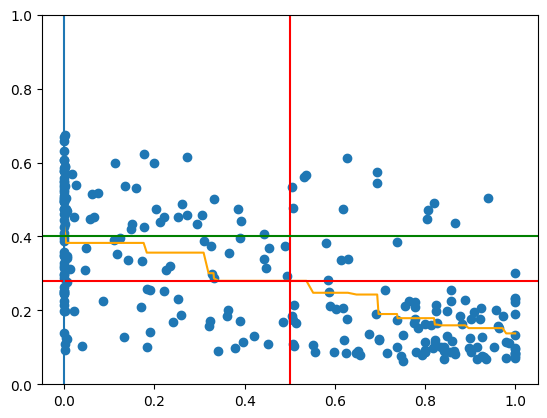

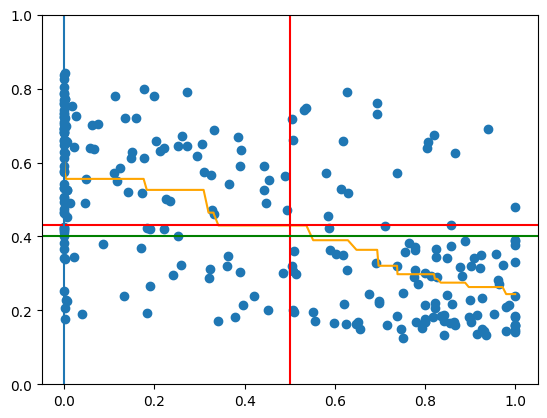

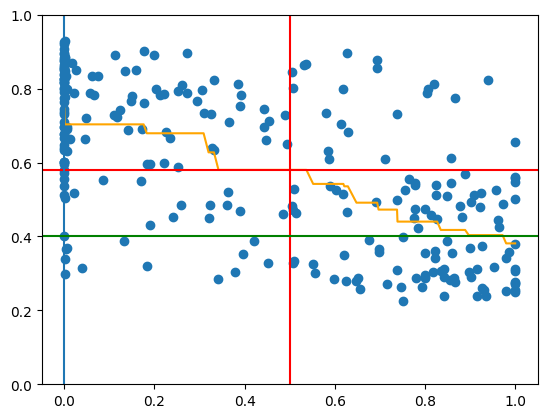

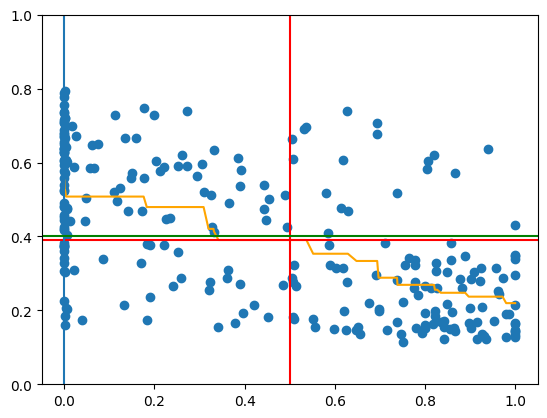

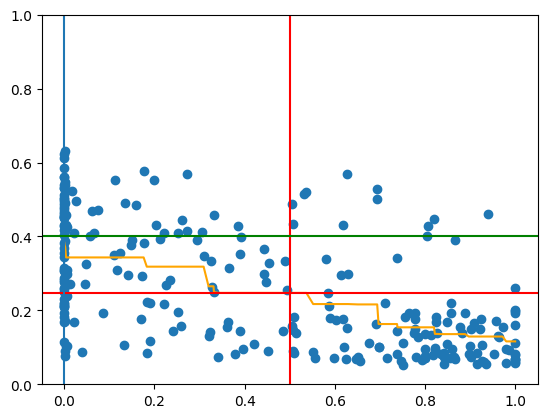

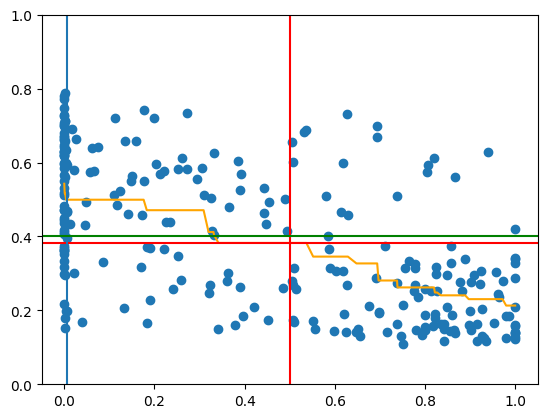

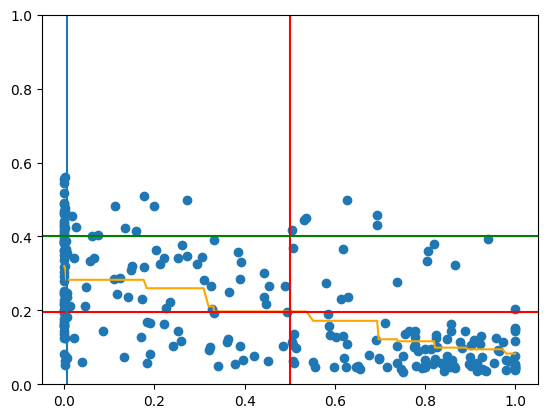

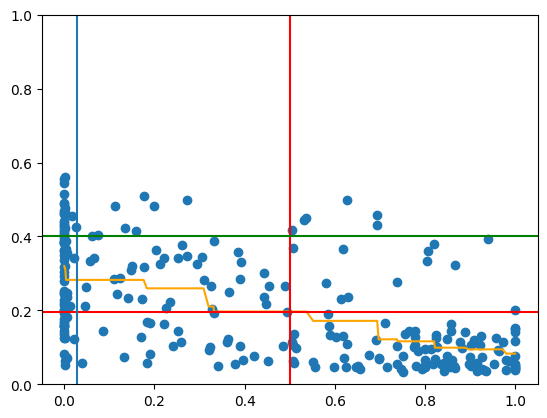

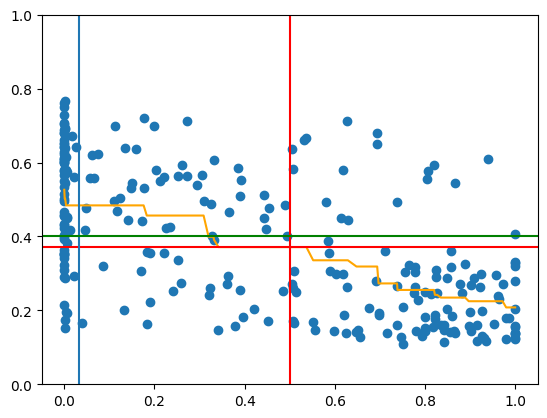

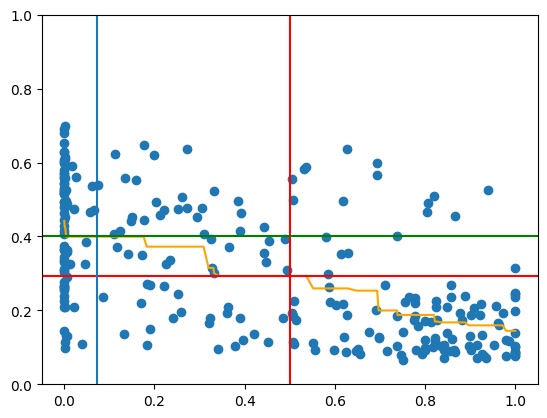

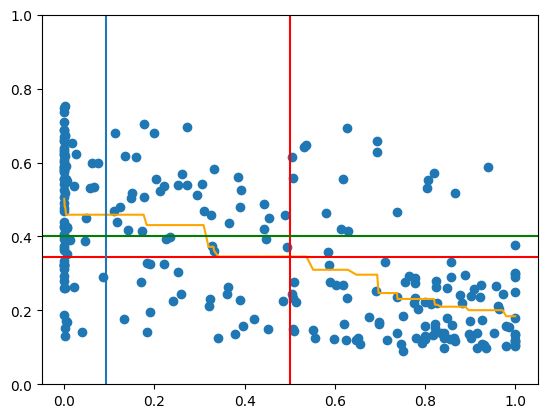

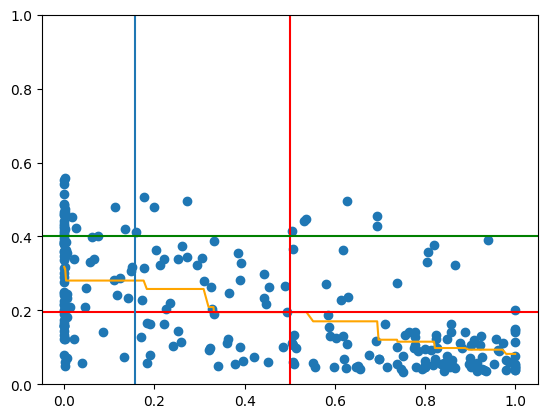

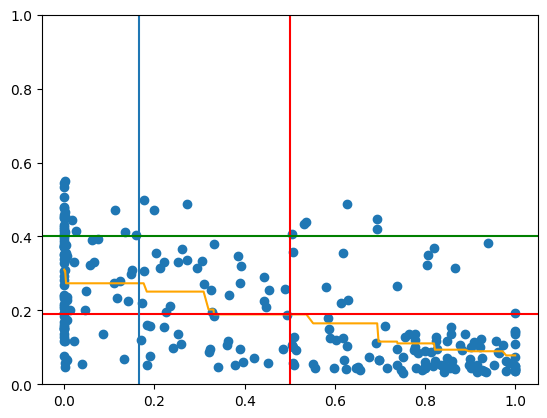

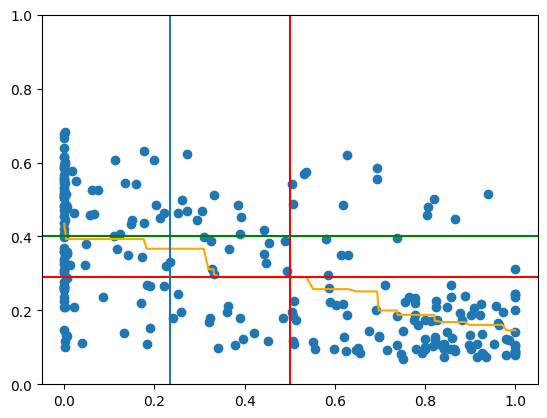

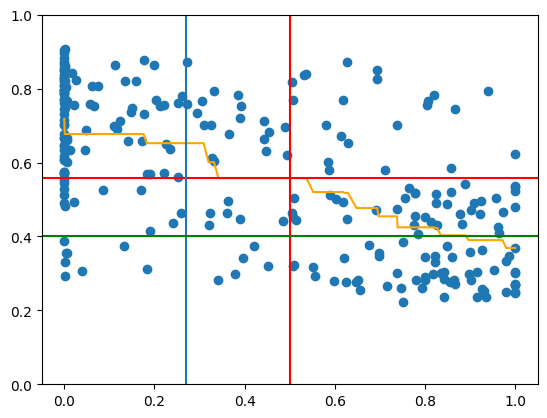

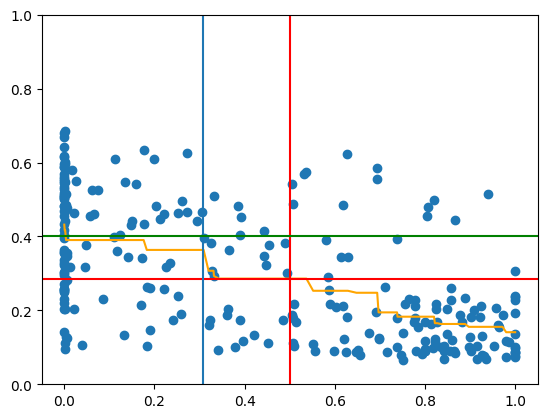

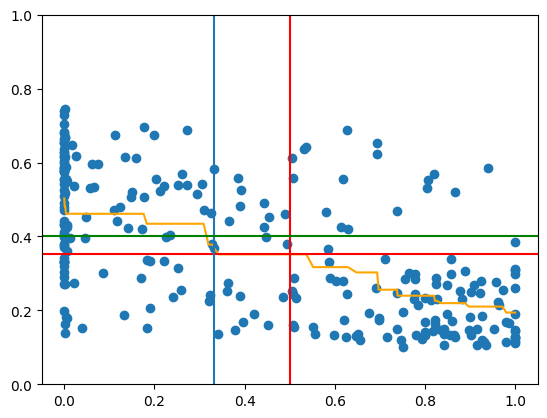

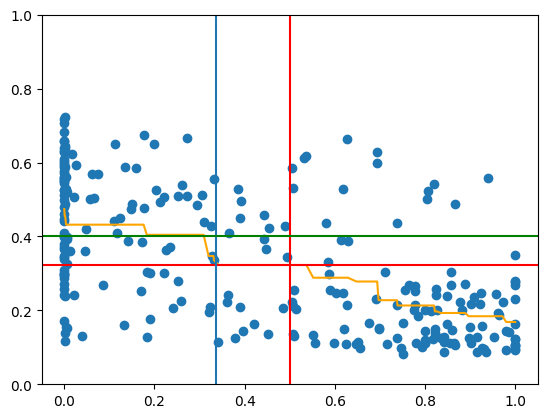

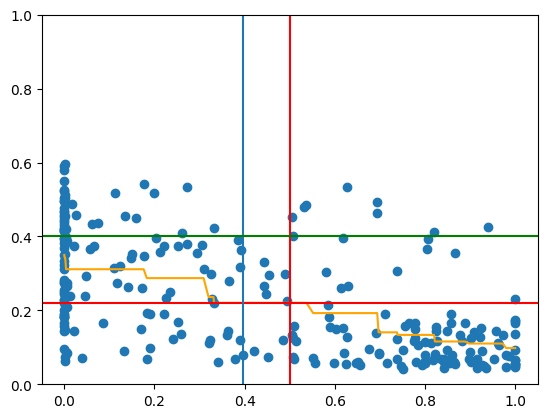

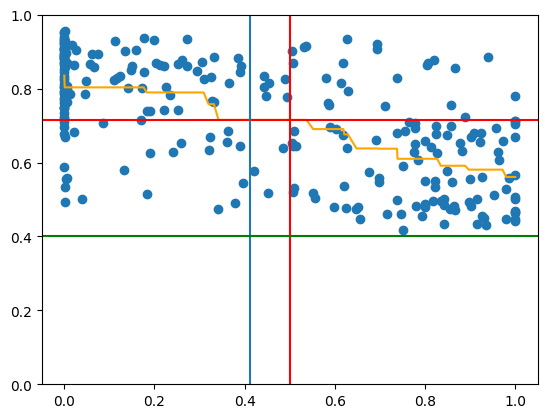

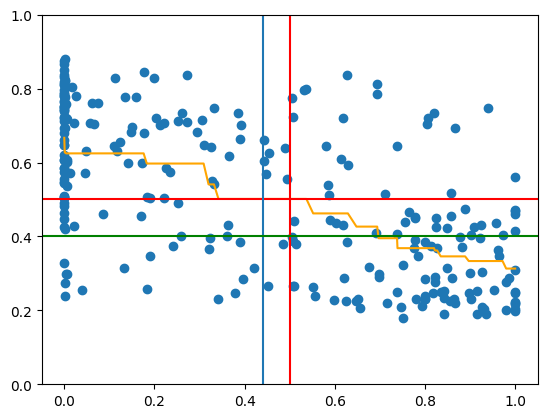

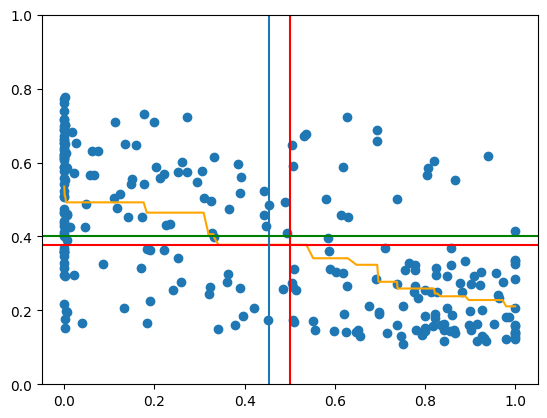

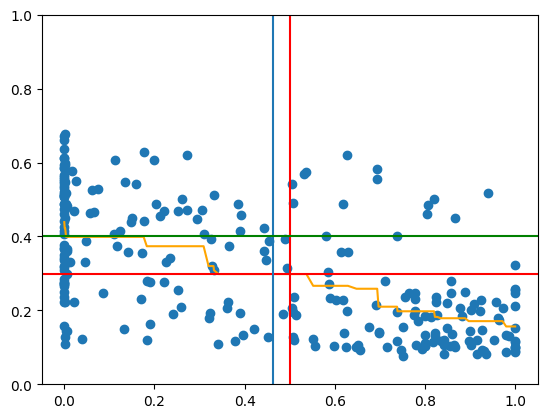

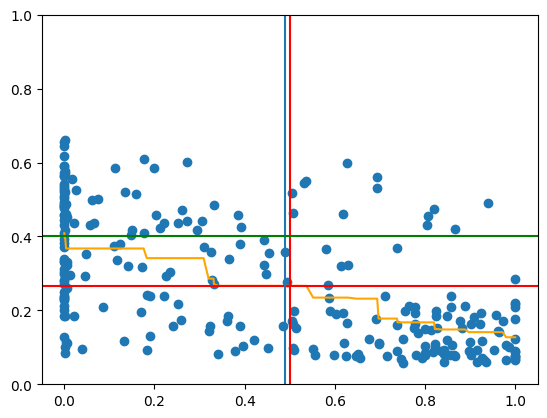

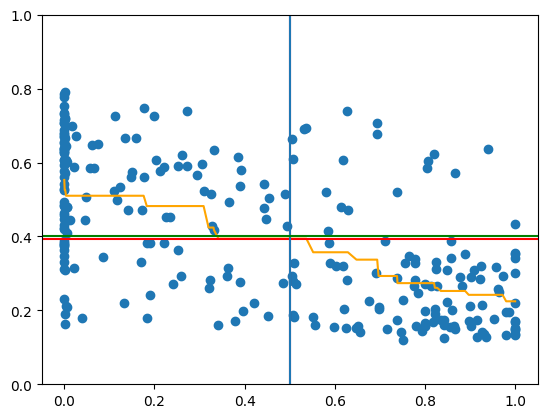

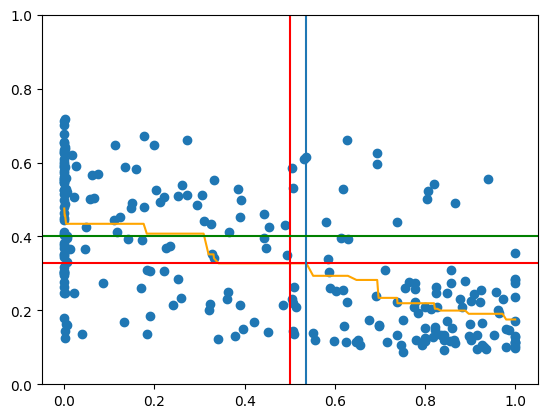

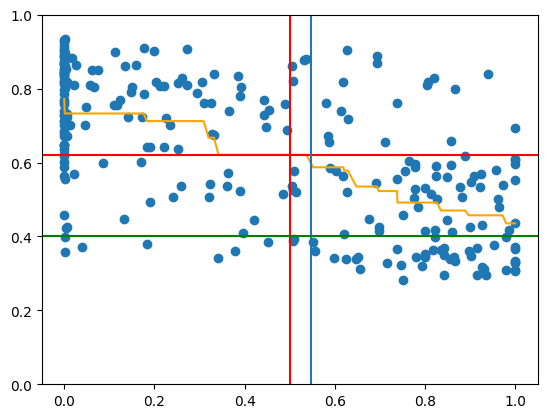

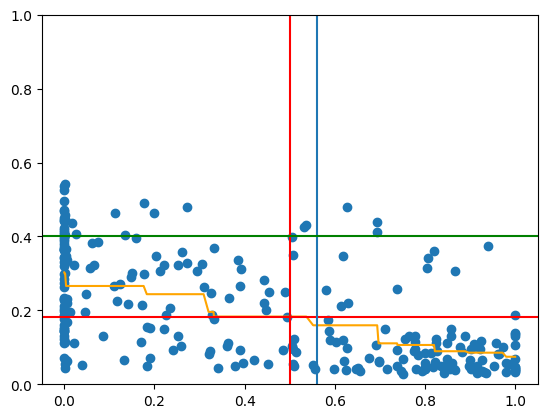

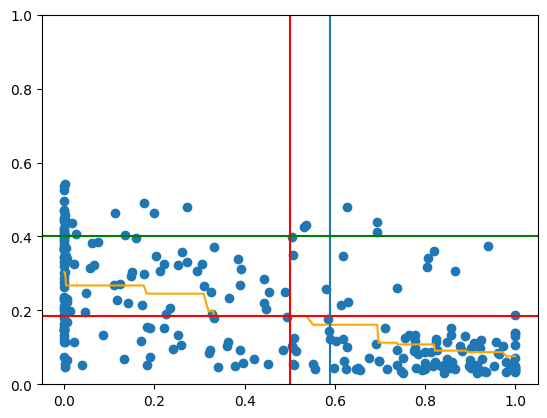

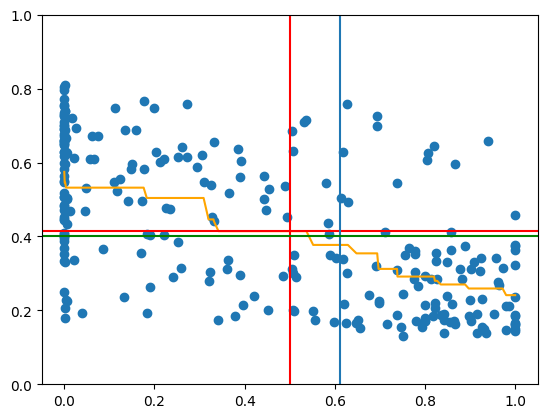

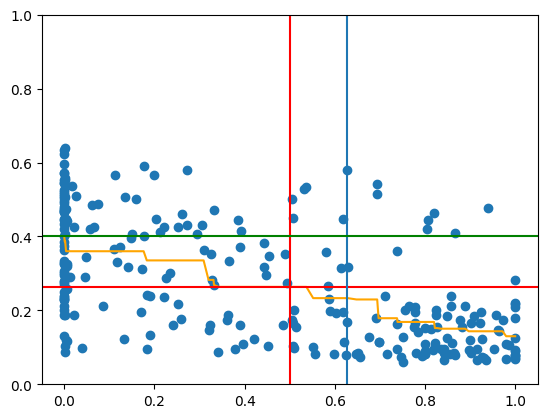

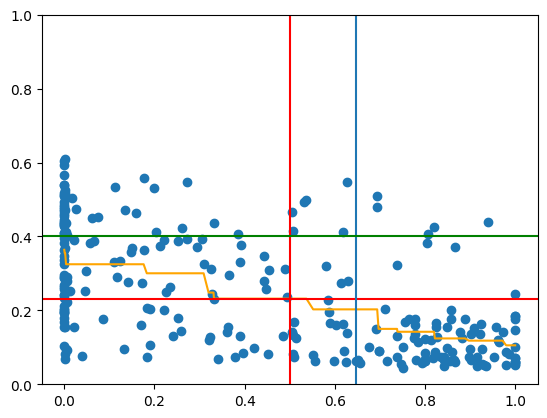

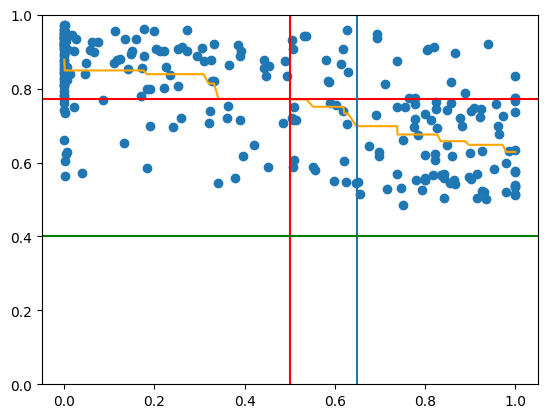

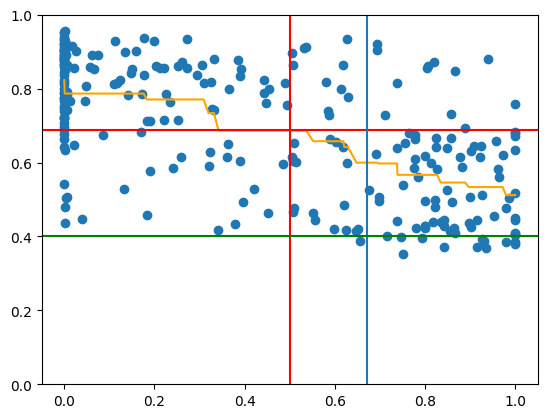

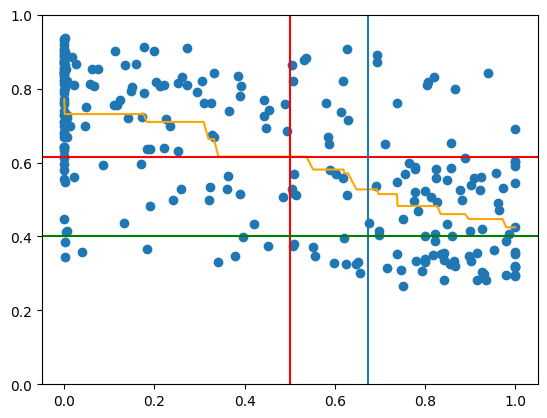

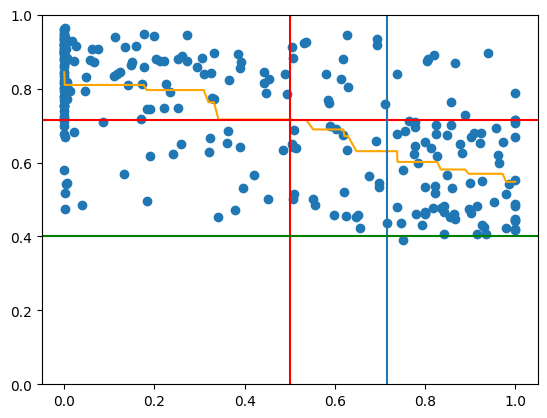

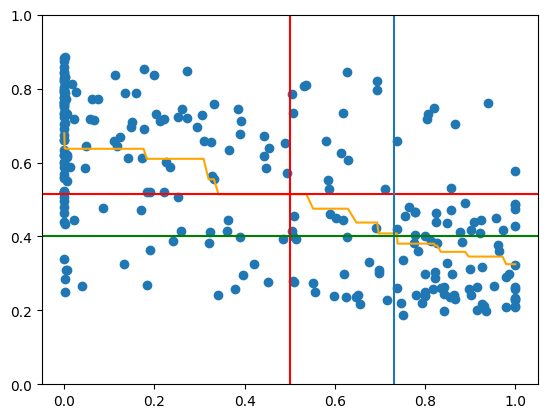

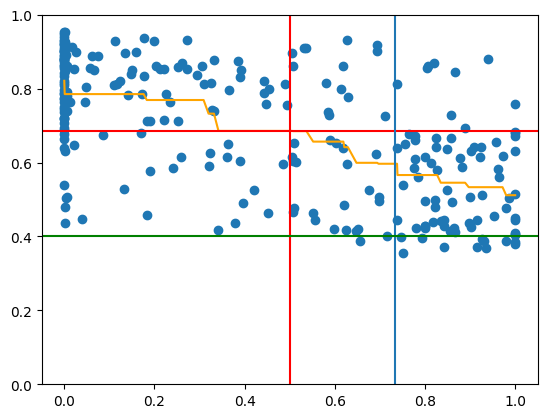

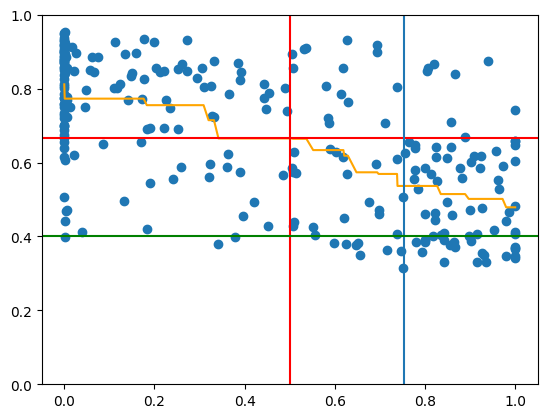

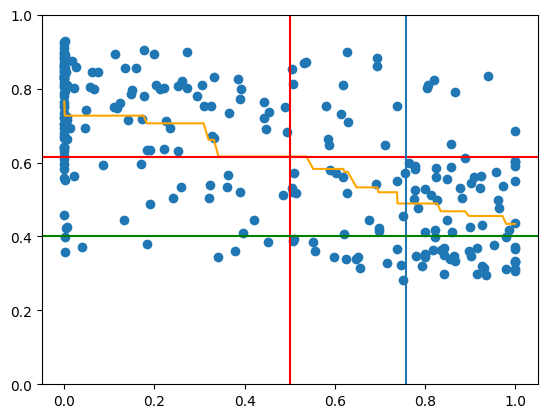

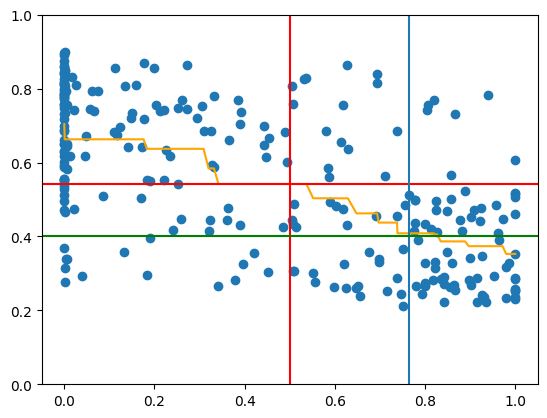

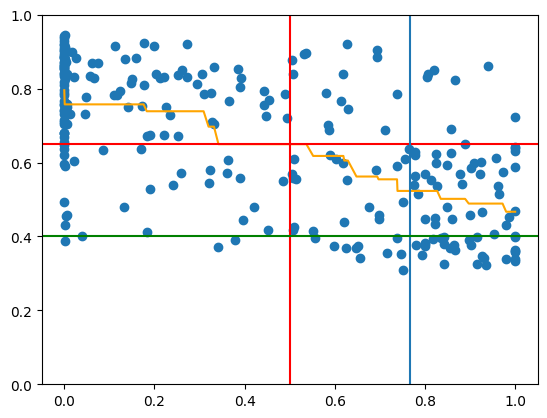

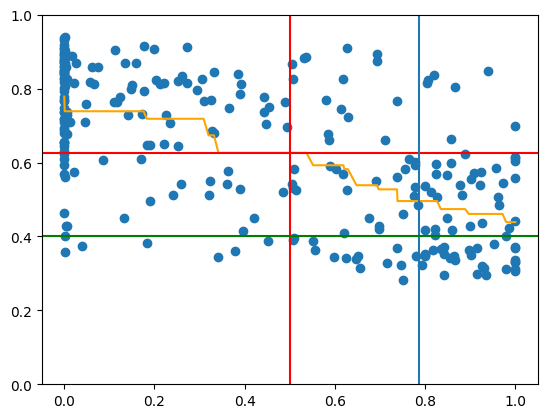

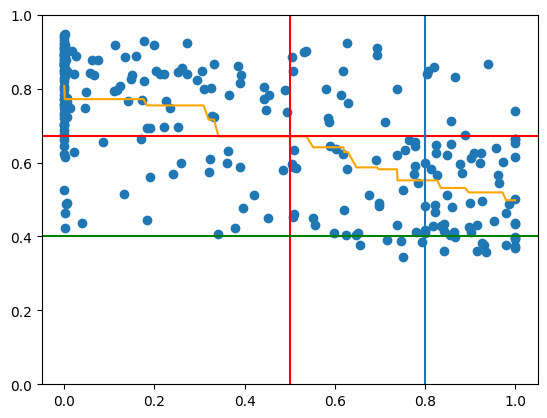

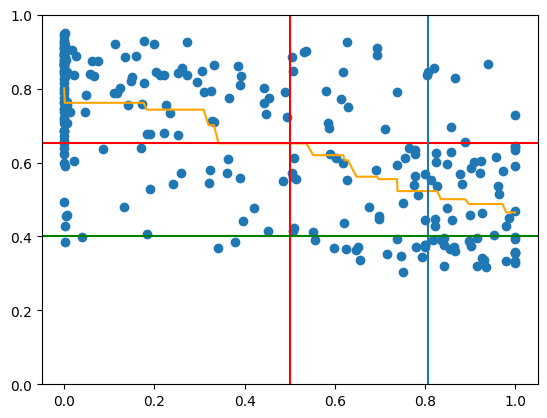

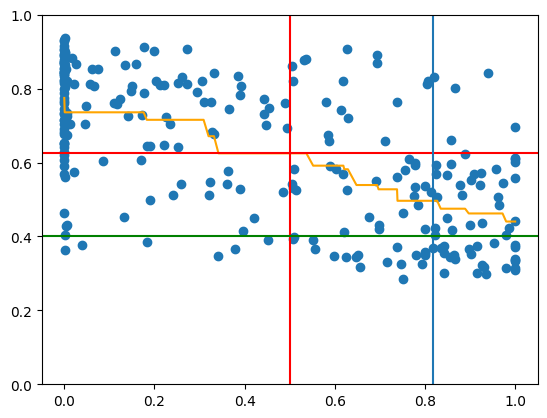

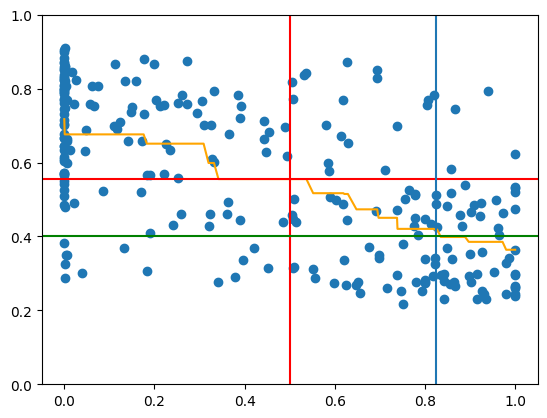

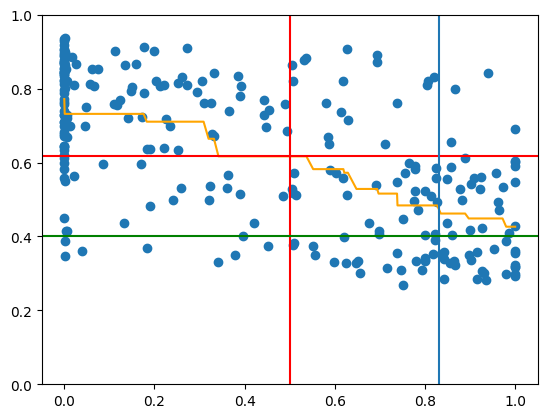

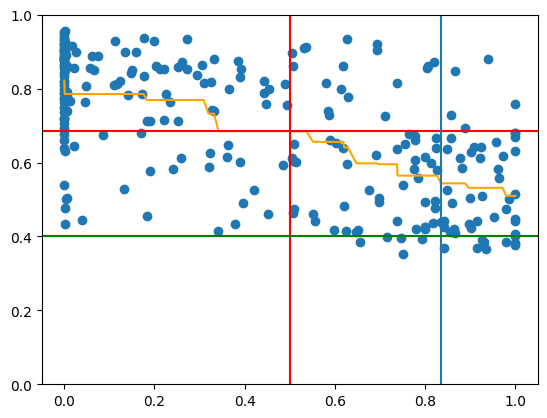

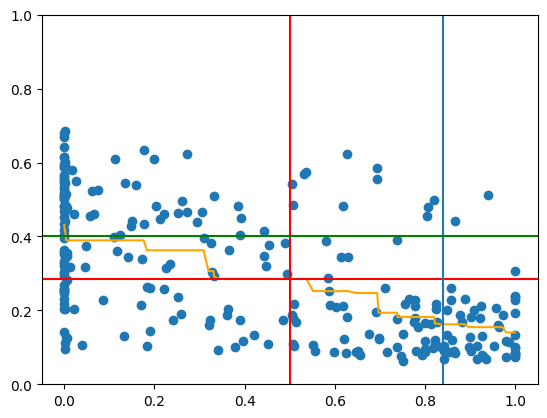

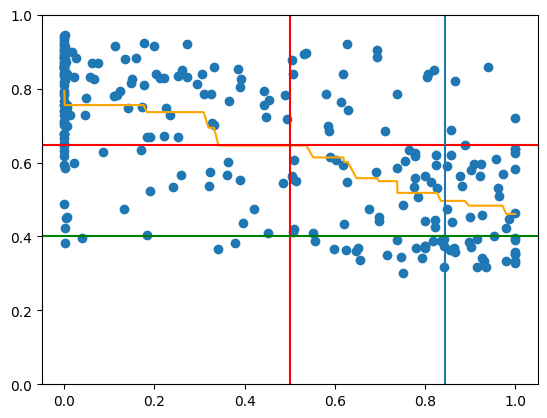

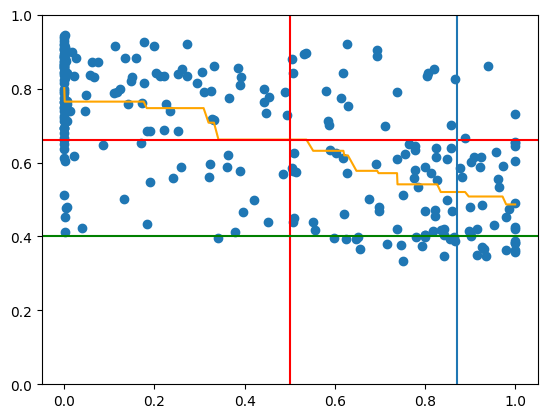

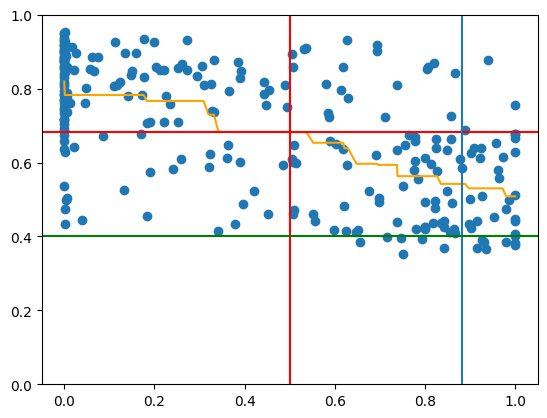

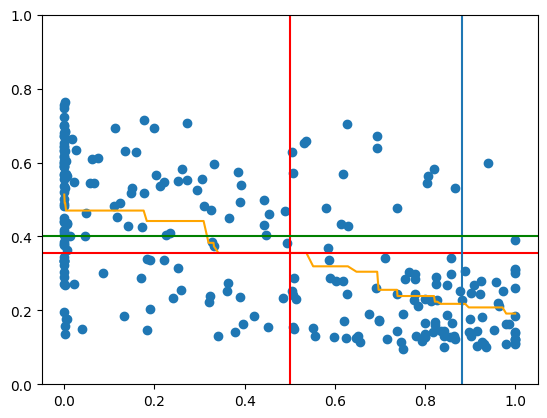

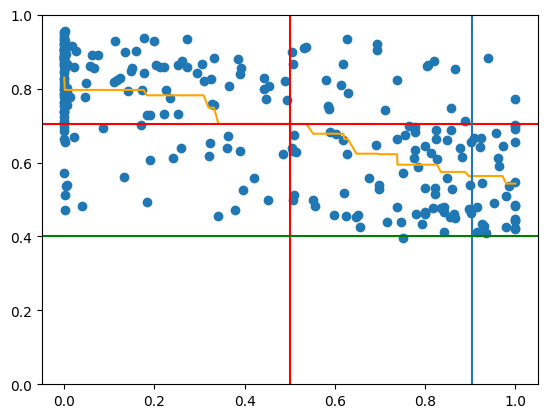

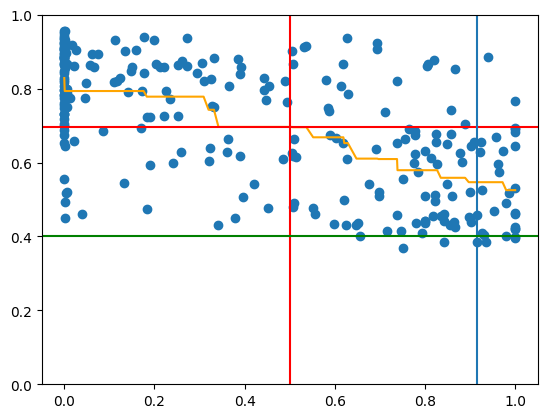

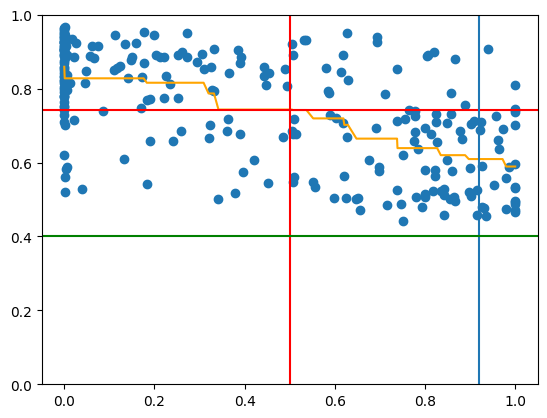

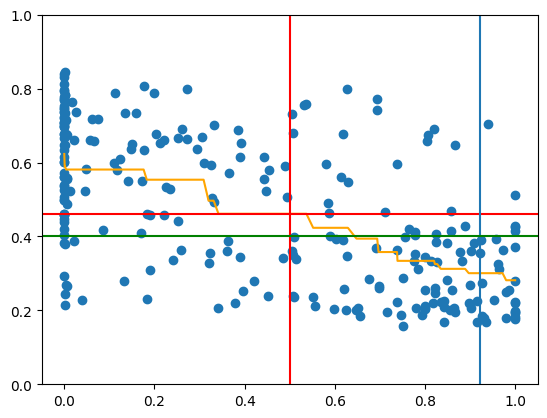

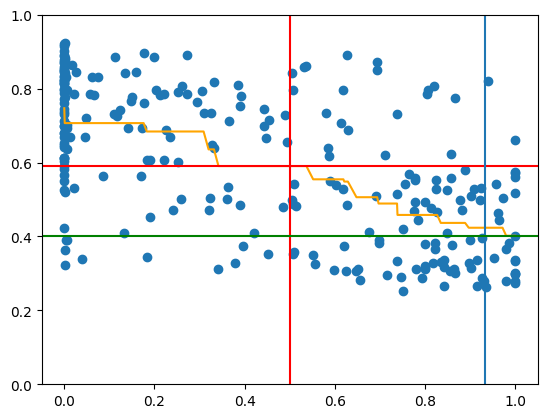

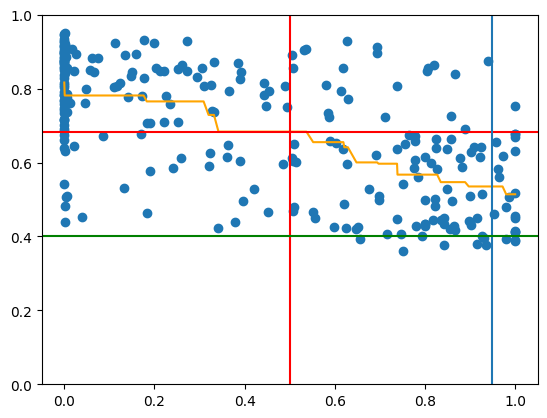

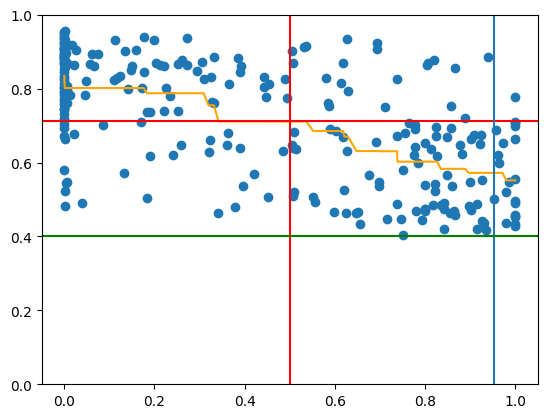

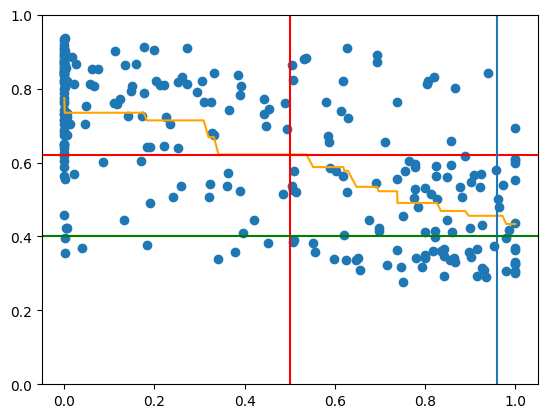

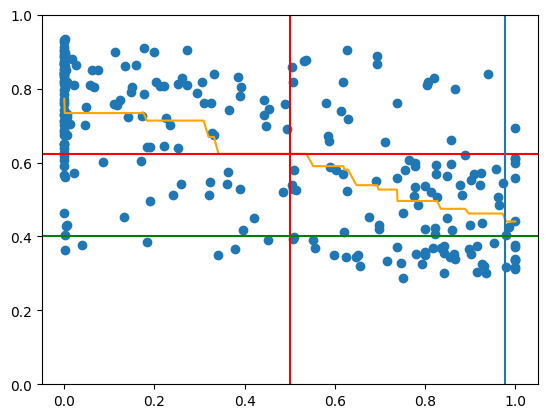

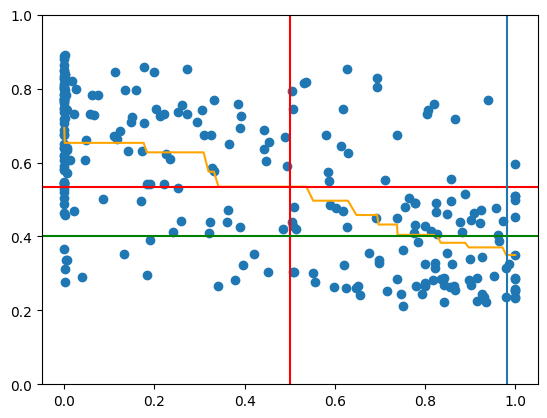

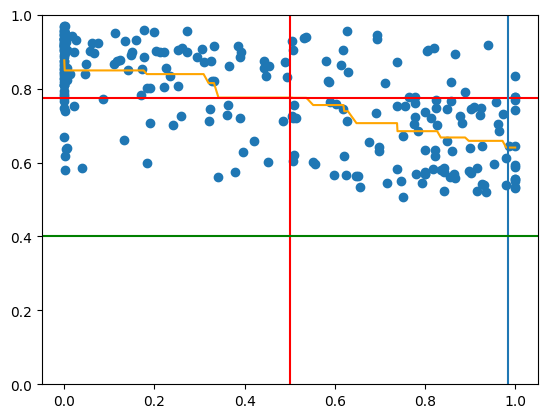

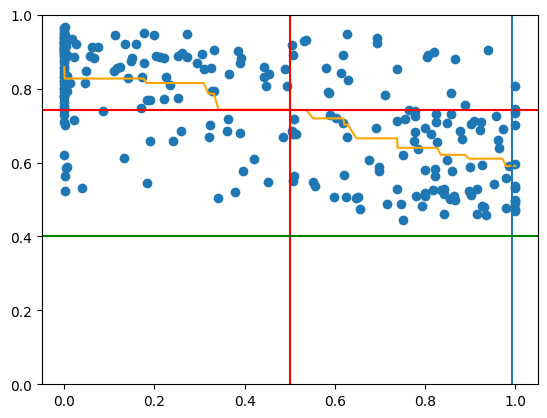

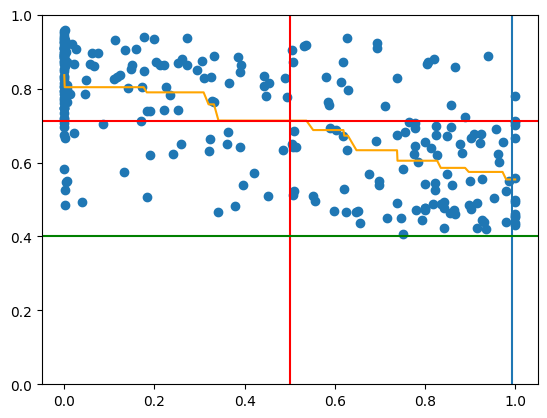

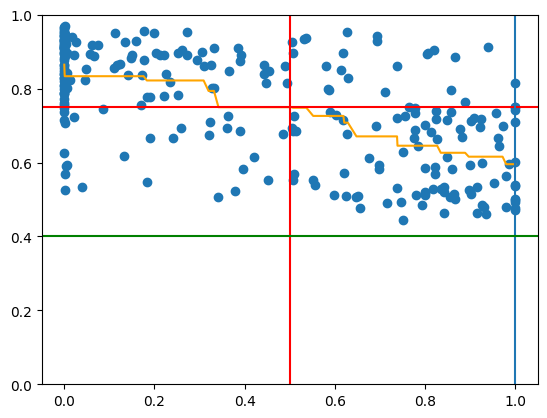

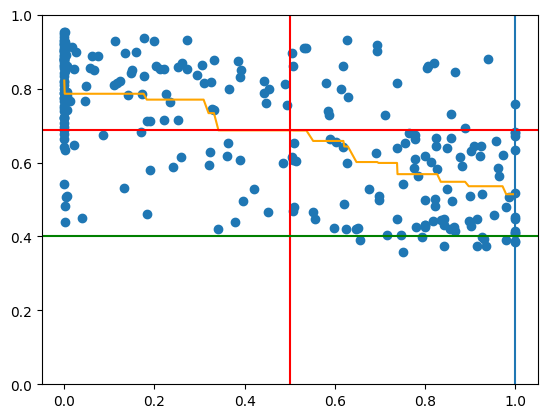

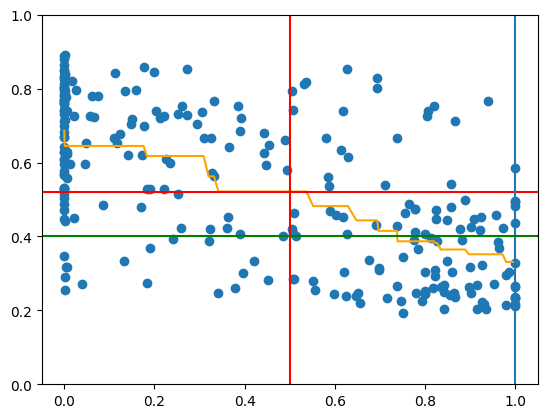

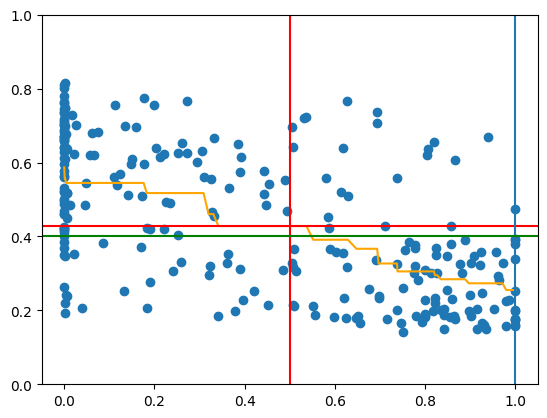

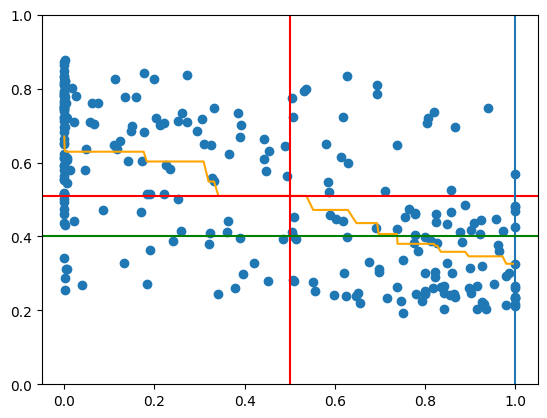

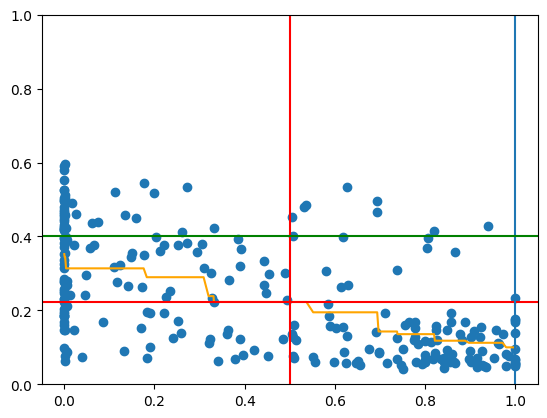

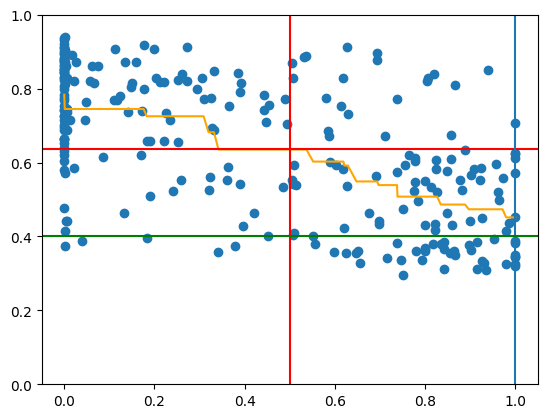

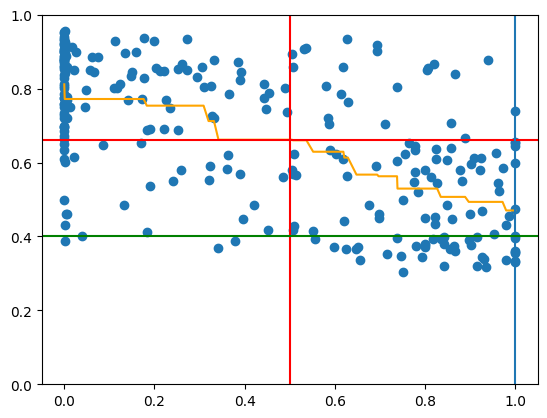

In [ ]:

for z in range(pred_probs.shape[0]):
    Y = pred_probs[z]
    X = train_df['reg_target'].to_numpy()
    sort_idxs = np.argsort(X)
    X = X[sort_idxs]
    Y = Y[sort_idxs]

    reg = IsotonicRegression(increasing=False, y_min=0, y_max=1.0)
    adj_Y = reg.fit_transform(X, Y)

    f = interp1d(X, adj_Y, kind="linear")
    plt.scatter(X, Y)
    plt.plot(X, adj_Y, color="orange")
    plt.axvline(1.5, color="red")
    plt.axhline(f(1.5), color="red")
    plt.axvline(test_df['reg_target'][z])
    plt.axhline(clf_th, color="green")
    plt.ylim(0, 1)
    plt.show()

In [ ]:
clf_th

np.float64(0.4)